# ACC 4x4 Bar Chart

This notebook draws a 4x4 grid of ACC bar charts from `src/result/acc.csv`.

- Row 1: 4 real graphs
- Row 2: 4 BA graphs
- Row 3: 4 WS graphs
- Row 4: 4 ER graphs

You can directly edit the graph selections, `EPSILON`, figure size, colors, and save path below.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="talk")

plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS",   # macOS 常见，兼容性好
    "PingFang SC",        # macOS
    "Heiti SC",           # macOS
    "SimHei",             # Windows
    "Microsoft YaHei",    # Windows
    "Noto Sans CJK SC",   # Linux
    "WenQuanYi Micro Hei" # Linux
]
plt.rcParams["axes.unicode_minus"] = False  # 防止负号显示成方块

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

BASE_DIR = Path.cwd()
if BASE_DIR.name != "src":
    BASE_DIR = BASE_DIR / "src"

ACC_PATH = BASE_DIR / "result_v1" / "acc.csv"
FIG_DIR = BASE_DIR / "result_v1" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

acc_df = pd.read_csv(ACC_PATH)
METHOD_ORDER = ["BP", "RK", "ABRA", "SILVAN", "GPU_SIR_BRIDGE"]
DISPLAY_METHOD_ORDER = ["BP", "RK", "ABRA", "SILVAN", "FastBC"]
BAR_COLORS = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"]

acc_df.head()

,graph_name,graph_source,num_nodes,num_edges,epsilon,top_k,top_k_ratio,exact_time,BP,RK,ABRA,SILVAN,GPU_SIR_BRIDGE
0,Celegans,real,297,2148,0.1,30,0.1,0.186838,0.700000,0.933333,0.933333,0.966667,0.933333
1,Fb-tvshow,real,3892,17262,0.1,390,0.1,37.199698,0.753846,0.753846,0.794872,0.894872,0.658974
2,Router,real,5022,6258,0.1,503,0.1,51.433398,0.681909,0.713718,0.745527,0.892644,0.787276
3,Soc-hamsterster,real,2000,16097,0.1,200,0.1,10.512955,0.715000,0.760000,0.855000,0.895000,0.845000
4,Yeast,real,2375,11693,0.1,238,0.1,12.704853,0.705882,0.773109,0.844538,0.894958,0.718487


In [5]:
EPSILON = 0.1

GRAPH_GROUPS = {
    "Real": ["bitcoin-alpha", "wiki-Vote",  "p2p-Gnutella06", "Soc-hamsterster"],
    "BA": ["BA1000", "BA2000", "BA3000", "BA5000"],
    "WS": ["WS1000", "WS2000", "WS3000", "WS5000"],
    "ER": ["ER1000", "ER2000", "ER3000", "ER5000"],
}

GRAPH_SOURCE = {
    "Real": "real",
    "BA": "synthetic",
    "WS": "synthetic",
    "ER": "synthetic",
}

available_real = sorted(acc_df.loc[acc_df["graph_source"] == "real", "graph_name"].unique())
available_synthetic = sorted(acc_df.loc[acc_df["graph_source"] == "synthetic", "graph_name"].unique())

print("Available real graphs:")
print(available_real)
print()
print("Available synthetic graphs:")
print(available_synthetic)

Available real graphs:
['Celegans', 'Fb-tvshow', 'Router', 'Soc-hamsterster', 'Yeast', 'bitcoin-alpha', 'ca-GrQc', 'cora', 'p2p-Gnutella06', 'wiki-Vote']

Available synthetic graphs:
['BA1000', 'BA10000', 'BA2000', 'BA3000', 'BA5000', 'ER1000', 'ER2000', 'ER3000', 'ER5000', 'WS1000', 'WS2000', 'WS3000', 'WS5000']


Saved figure to: /Users/zhangjuyuan/Documents/projects/FastBC/src/result_v1/figures/acc_bar_grid_4x4.png


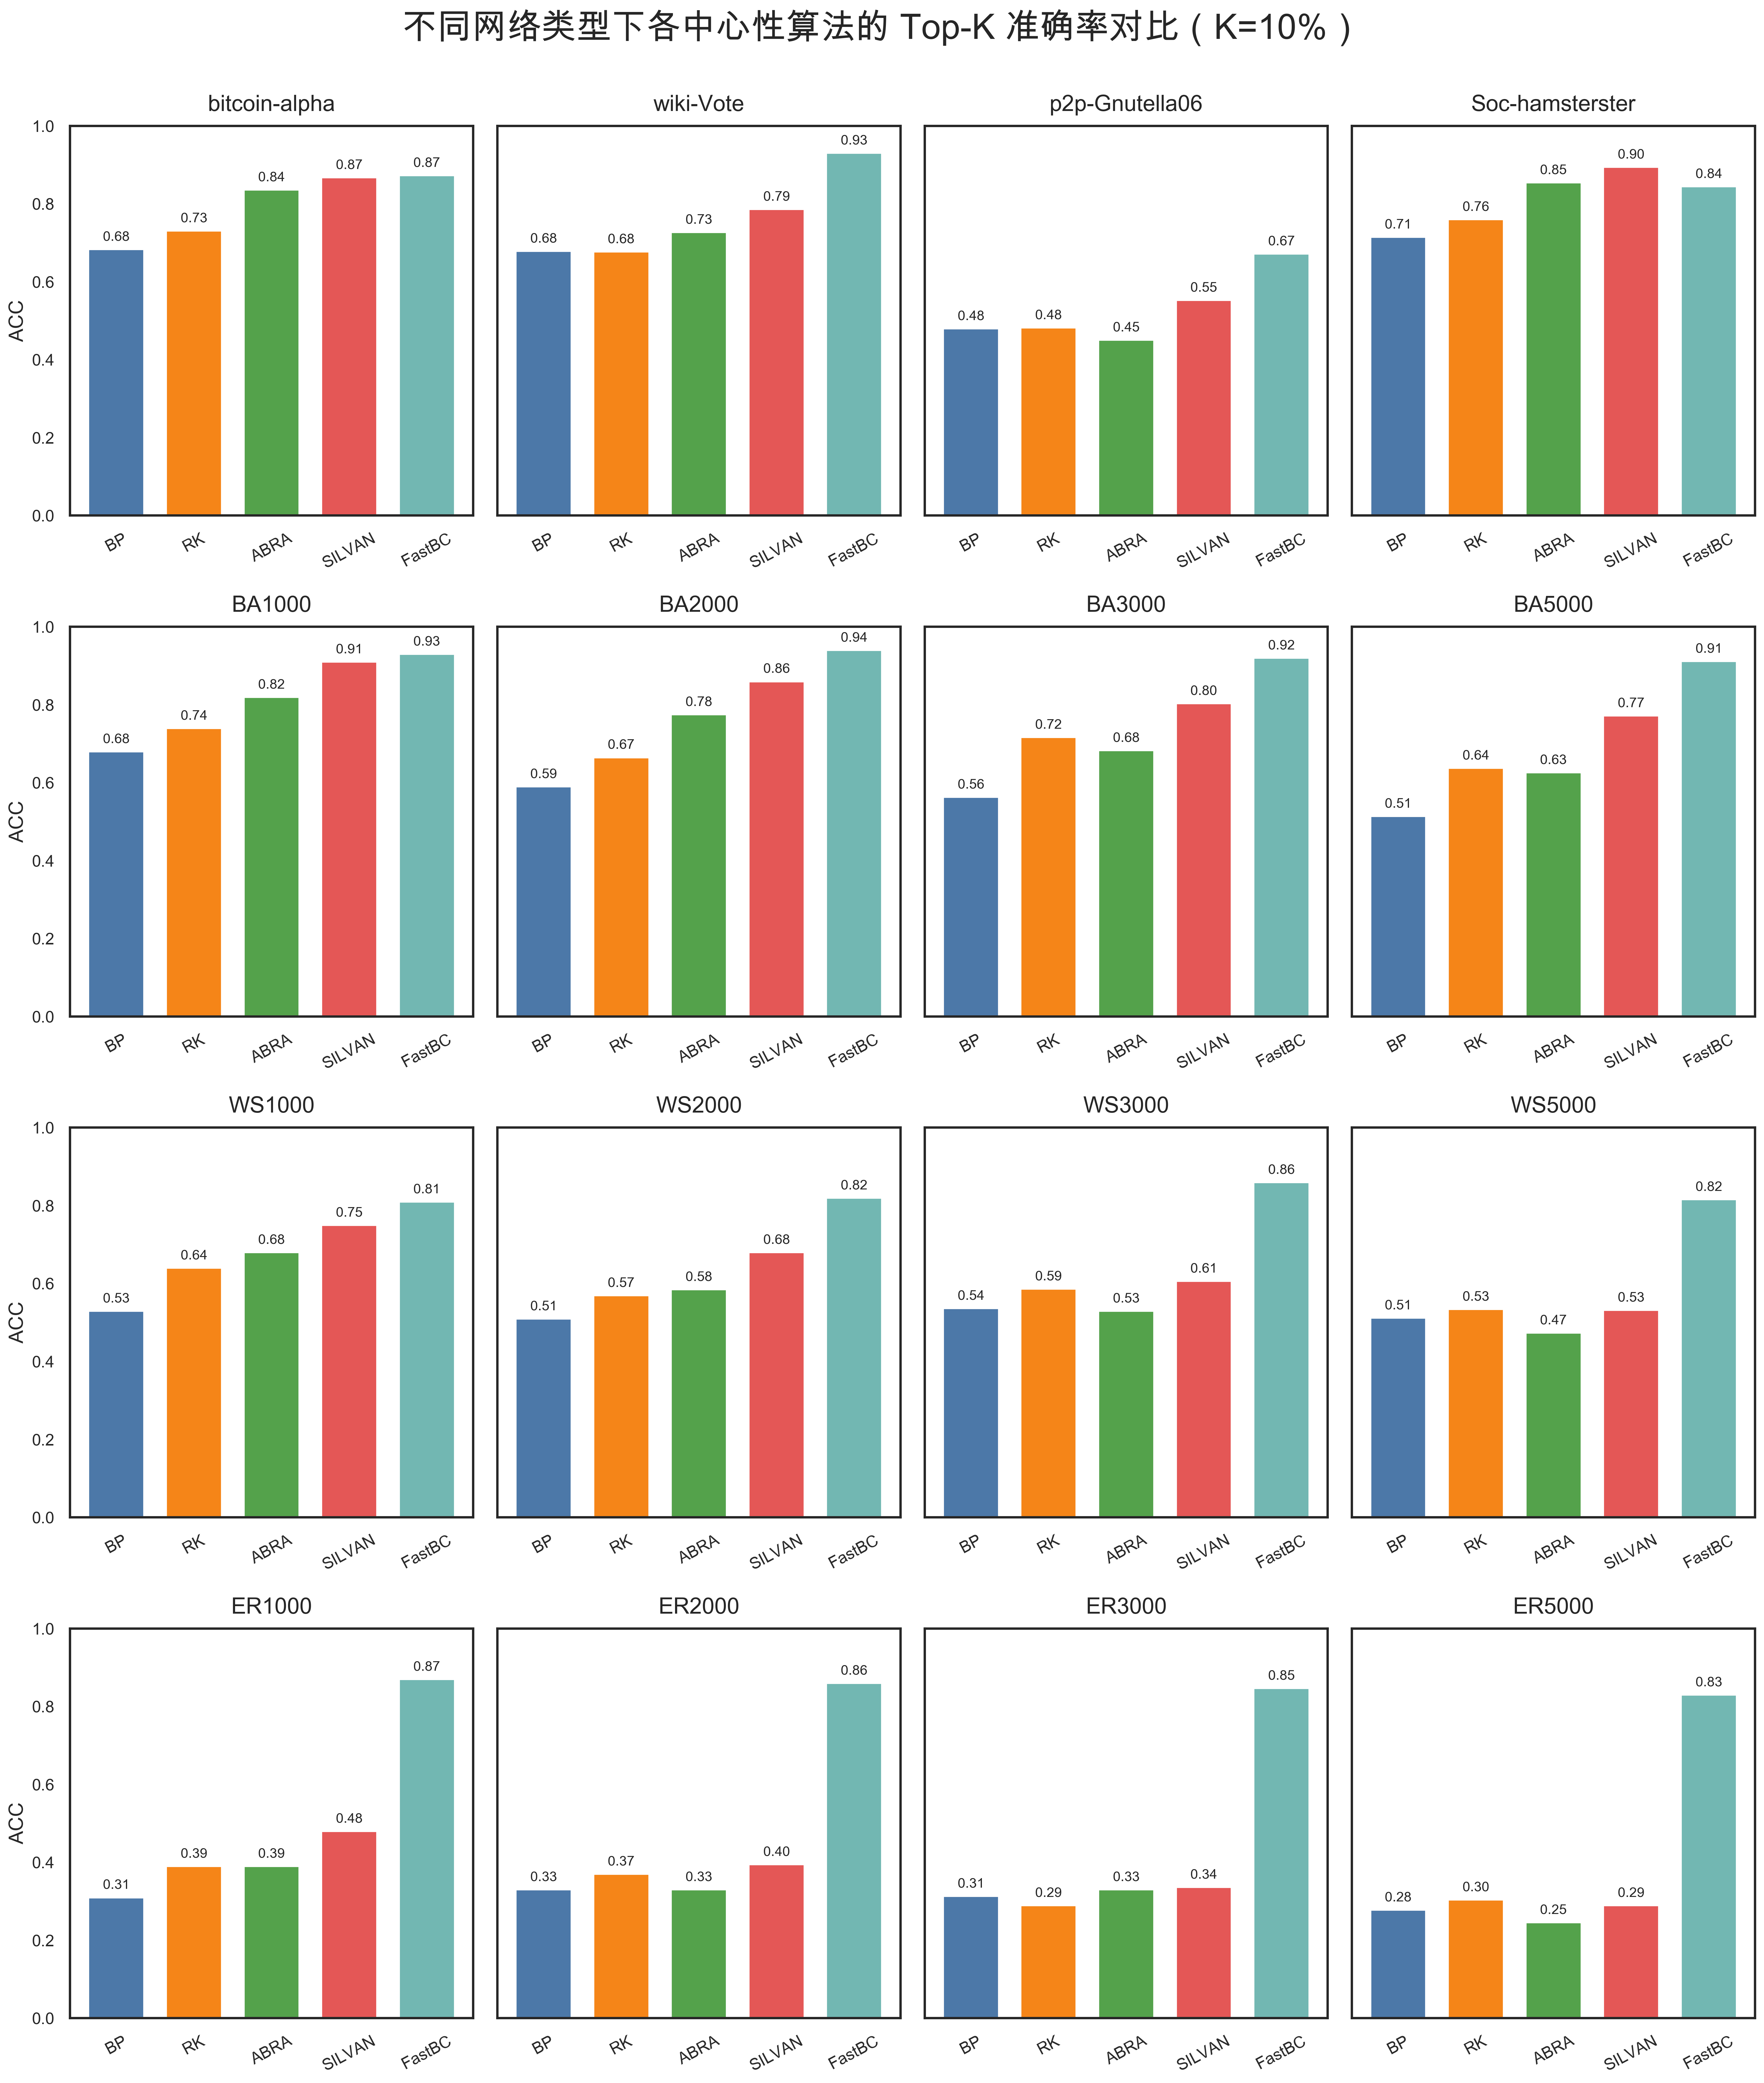

In [6]:
plot_df = acc_df.loc[acc_df["epsilon"] == EPSILON].copy()

fig, axes = plt.subplots(4, 4, figsize=(20, 24), sharey=True)
fig.suptitle(f"不同网络类型下各中心性算法的 Top-K 准确率对比（K=10%）", fontsize=28, fontweight="bold", y=0.97)

for row_idx, (group_name, graph_names) in enumerate(GRAPH_GROUPS.items()):
    expected_source = GRAPH_SOURCE[group_name]
    for col_idx, graph_name in enumerate(graph_names):
        ax = axes[row_idx, col_idx]
        row = plot_df.loc[
            (plot_df["graph_source"] == expected_source)
            & (plot_df["graph_name"] == graph_name)
        ]

        if row.empty:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f"Missing\n{graph_name}", ha="center", va="center", fontsize=16, fontweight="bold")
            continue

        values = row.iloc[0][METHOD_ORDER].astype(float)
        bars = ax.bar(DISPLAY_METHOD_ORDER, values, color=BAR_COLORS, width=0.72)
        ax.set_title(graph_name, fontsize=18, fontweight="bold", pad=12)
        ax.set_ylim(0.0, 1.0)
        ax.tick_params(axis="x", rotation=28, labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
        ax.grid(False)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        if col_idx == 0:
            ax.set_ylabel("ACC", fontsize=16, fontweight="bold")

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                min(value + 0.015, 0.985),
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                rotation=0,
            )

# for ax in axes[-1, :]:
#     ax.set_xlabel("Method", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.97])
save_path = FIG_DIR / "acc_bar_grid_4x4.png"
fig.savefig(save_path, bbox_inches="tight")
print(f"Saved figure to: {save_path}")
plt.show()